# 07 · Brain visualization

Map per-parcel / per-voxel model scores onto the cortex. The parcel heatmap is local; the inflated cortical surface needs nilearn + fsaverage assets and is an optional EC2 path.


In [1]:
import warnings
warnings.filterwarnings('ignore', message='xarray subclass Score should explicitly define __slots__', category=FutureWarning)

import numpy as np
from brainscore.visualization import (parcel_grid_heatmap, network_strip,
    cortical_surface_map)
# pretend per-parcel prediction r for 1000 Schaefer parcels
rng=np.random.RandomState(0); per_parcel_r = np.clip(rng.rand(1000)*0.4, 0, 1)

## Parcel heatmap

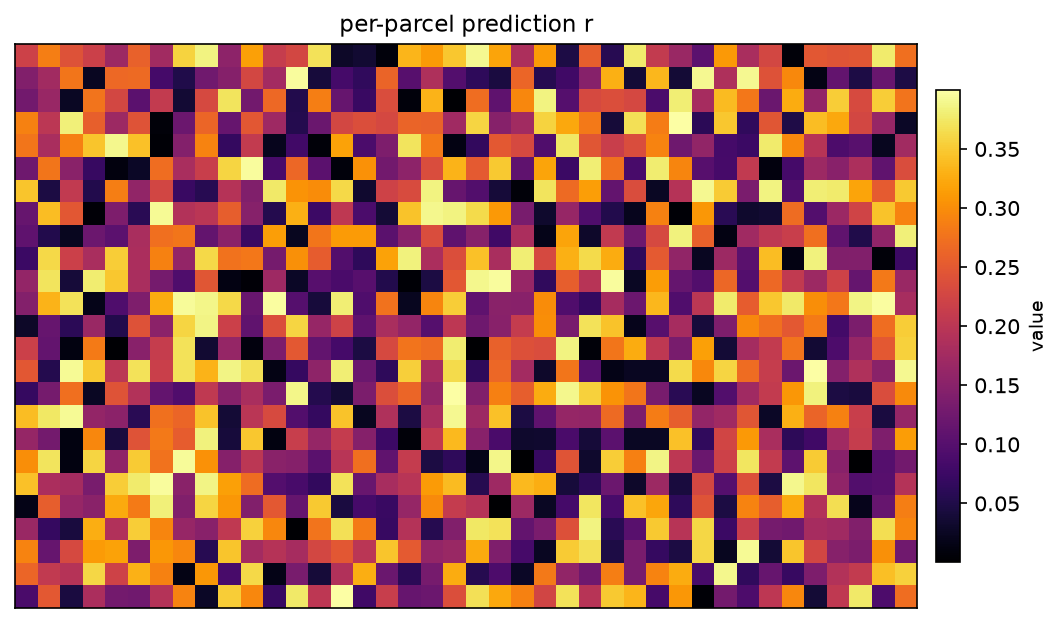

parcel values: (1000,) range: (0.00021838595879826174, 0.39992343124678614)
wrote plot: /var/folders/h6/g53mxg516n538136hh74630r0000gn/T/parcels_demo.png


In [2]:
from pathlib import Path
import tempfile
from IPython.display import Image, display

out_png = Path(tempfile.gettempdir()) / 'parcels_demo.png'
parcel_grid_heatmap(per_parcel_r, title='per-parcel prediction r',
                    out_png=str(out_png))
display(Image(str(out_png)))
print('parcel values:', per_parcel_r.shape, 'range:', (float(per_parcel_r.min()), float(per_parcel_r.max())))
print('wrote plot:', out_png)


## Optional inflated-cortex surface

This cell is skipped by default because nilearn may download fsaverage and Schaefer assets. Set `BRAINSCORE_RUN_OPTIONAL_SURFACE=1` before starting Jupyter to opt in.

In [3]:
import os

if os.environ.get('BRAINSCORE_RUN_OPTIONAL_SURFACE') != '1':
    print('skipped optional surface render; set BRAINSCORE_RUN_OPTIONAL_SURFACE=1 to allow downloads')
else:
    from pathlib import Path
    import tempfile
    from IPython.display import Image as DisplayImage, display
    try:
        out_png = Path(tempfile.gettempdir()) / 'surface_demo.png'
        cortical_surface_map(per_parcel_r, hemi='left', view='lateral',
                             title='model response on cortex', out_png=str(out_png))
        display(DisplayImage(str(out_png)))
        print('surface render succeeded:', out_png)
    except Exception as error:
        print('optional surface render failed:', type(error).__name__, str(error)[:160])


skipped optional surface render; set BRAINSCORE_RUN_OPTIONAL_SURFACE=1 to allow downloads
